<a href="https://colab.research.google.com/github/maps-05/portfolio/blob/main/gmm_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Mixture Model (GMM) Clustering

Name: RELATIVO, Muffle P.

Section: BsCPE IV - GE

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-data-m4.csv')
df

,x1,x2
0,2.126952,-1.184678
1,-0.092511,-1.056807
2,-0.184778,0.716297
3,1.060384,1.489656
4,3.932968,-0.177123
...,...,...
995,-2.649776,-1.864049
996,0.457076,1.051936
997,4.235872,1.682789
998,1.788743,0.564541


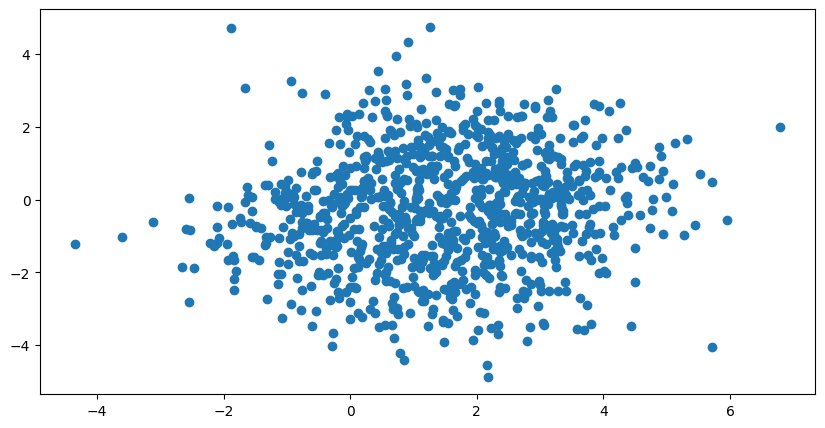

In [ ]:
# Visualization

plt.figure(figsize = (10,5))
plt.scatter(df['x1'], df['x2'])

plt.show()

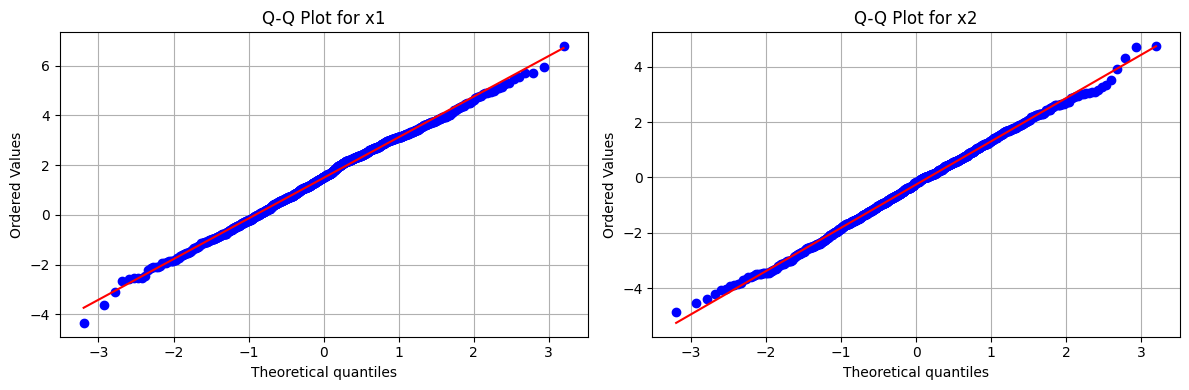

In [ ]:
# Test for Gaussianity (Normal Distribution) using Q-Q Plot

import scipy.stats as stats

# Generate Q-Q plots for x1 and x2

plt.figure(figsize=(12, 4))

for i, feature in enumerate(['x1', 'x2'], 1):

  plt.subplot(1, 2, i) # 1 row, 2 columns
  stats.probplot(df[feature], dist = 'norm', plot = plt)
  plt.grid()
  plt.title(f'Q-Q Plot for {feature}')

plt.tight_layout()
plt.show()

In [ ]:
shapiro_test_x = stats.shapiro(df['x1'])
shapiro_test_y = stats.shapiro(df['x2'])

shapiro_test_x, shapiro_test_y

(ShapiroResult(statistic=np.float64(0.9972187263490253), pvalue=np.float64(0.0820117216379872)),
 ShapiroResult(statistic=np.float64(0.9981782488796702), pvalue=np.float64(0.36547310523977417)))

In [ ]:
ks_test_x = stats.kstest(df['x1'], 'norm', args=(df['x1'].mean(), df['x1'].std()))
ks_test_y = stats.kstest(df['x2'], 'norm', args=(df['x2'].mean(), df['x2'].std()))
ks_test_x, ks_test_y

(KstestResult(statistic=np.float64(0.04082467869256057), pvalue=np.float64(0.06939610727780376), statistic_location=np.float64(2.1407375881284403), statistic_sign=np.int8(-1)),
 KstestResult(statistic=np.float64(0.022281917315081), pvalue=np.float64(0.6948560611293415), statistic_location=np.float64(-0.0357266344632603), statistic_sign=np.int8(-1)))

In [ ]:
skewness_x = stats.skew(df['x1'])
skewness_y = stats.skew(df['x2'])
skewness_x, skewness_y


(np.float64(-0.12133273629565523), np.float64(-0.044932092010736516))

In [ ]:
kurtosis_x = stats.kurtosis(df['x1'])
kurtosis_y = stats.kurtosis(df['x2'])

kurtosis_x, kurtosis_y

(np.float64(-0.18212138932126187), np.float64(-0.20316579840875493))

In [ ]:
from sklearn.mixture import GaussianMixture

n_clusters_range = range(1, 11)  # Try 1 to 10 clusters

bic_scores = []
aic_scores = []

for n_clusters in n_clusters_range:

    gmm = GaussianMixture(n_components = n_clusters, random_state = 101)
    gmm.fit(df)
    bic_scores.append(gmm.bic(df))
    aic_scores.append(gmm.aic(df))

# Return the BIC and AIC scores for each number of clusters

bic_scores, aic_scores

([np.float64(7565.1132084760575),
  np.float64(7564.515919166647),
  np.float64(7590.253660996919),
  np.float64(7628.015897505393),
  np.float64(7657.257344115561),
  np.float64(7695.707160714765),
  np.float64(7734.723737598233),
  np.float64(7768.159367204529),
  np.float64(7794.637312426152),
  np.float64(7830.474133232612)],
 [np.float64(7540.574432081146),
  np.float64(7510.530611097844),
  np.float64(7506.821821254223),
  np.float64(7515.1375260888035),
  np.float64(7514.932441025079),
  np.float64(7523.93572595039),
  np.float64(7533.505771159966),
  np.float64(7537.494869092368),
  np.float64(7534.5262826400985),
  np.float64(7540.916571772666)])

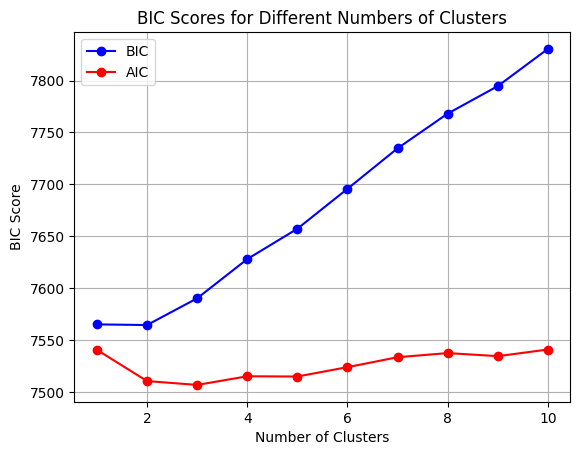

In [ ]:
plt.plot(n_clusters_range, bic_scores, marker='o', color = 'blue', label = 'BIC')
plt.plot(n_clusters_range, aic_scores, marker='o', color = 'red', label = 'AIC')
plt.title('BIC Scores for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('BIC Score')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for n_clusters in [2, 3, 4, 5, 6, 7, 8]:

    # Fit GMM with n_clusters
    gmm = GaussianMixture(n_components = n_clusters, random_state = 101)
    labels = gmm.fit_predict(df)

    # Calculate the silhouette score
    score = silhouette_score(df, labels)
    silhouette_scores[n_clusters] = score

silhouette_scores

{2: np.float64(0.3535776499341234),
 3: np.float64(0.34812706671475907),
 4: np.float64(0.3462857288002005),
 5: np.float64(0.3123869620841945),
 6: np.float64(0.27633270105093116),
 7: np.float64(0.3106933430954746),
 8: np.float64(0.29799571540347247)}

In [ ]:

from sklearn.metrics import davies_bouldin_score

# Try GMM with different numbers of clusters and calculate DBI

dbi_scores = []
n_clusters_range = [2, 3, 4, 5, 6]

for n in n_clusters_range:

    gmm = GaussianMixture(n_components = n, random_state = 101)
    labels = gmm.fit_predict(df)
    score = davies_bouldin_score(df, labels)
    dbi_scores.append(score)
    print(f"Number of Clusters: {n}, DBI: {score}")

# Find the number of clusters with the lowest DBI
best_n_clusters_dbi = n_clusters_range[np.argmin(dbi_scores)]
print(f"\nBest number of clusters according to DBI: {best_n_clusters_dbi}")


Number of Clusters: 2, DBI: 1.1277320034185383
Number of Clusters: 3, DBI: 0.9189339011421919
Number of Clusters: 4, DBI: 0.8962534353949044
Number of Clusters: 5, DBI: 0.9598810177871899
Number of Clusters: 6, DBI: 0.9523669198085621

Best number of clusters according to DBI: 4


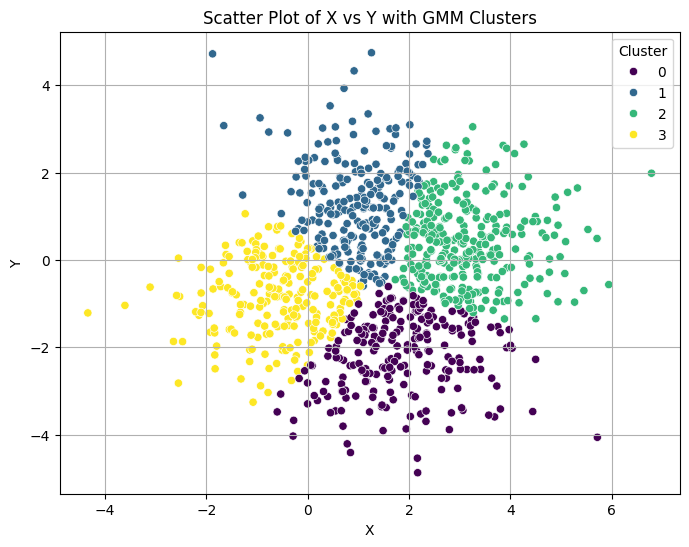

In [ ]:
gmm = GaussianMixture(n_components = 4, random_state = 101)
gmm.fit(df)

# Predict the cluster labels
df['Cluster'] = pd.DataFrame(gmm.predict(df))
# df_scaled['Cluster'] = df_scaled['Cluster'].apply(lambda x: f'Cluster {x}')

# Plot the scatter plot with GMM clusters
plt.figure(figsize = (8, 6))

sns.scatterplot(x = df['x1'], y = df['x2'], data = df, palette = 'viridis', hue = 'Cluster')

plt.title('Scatter Plot of X vs Y with GMM Clusters')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.show()

In [ ]:
cluster_of_index_500 = df.loc[500, 'Cluster']
print(f"The data point at index 500 belongs to GMM cluster: {cluster_of_index_500}")

The data point at index 500 belongs to GMM cluster: 0


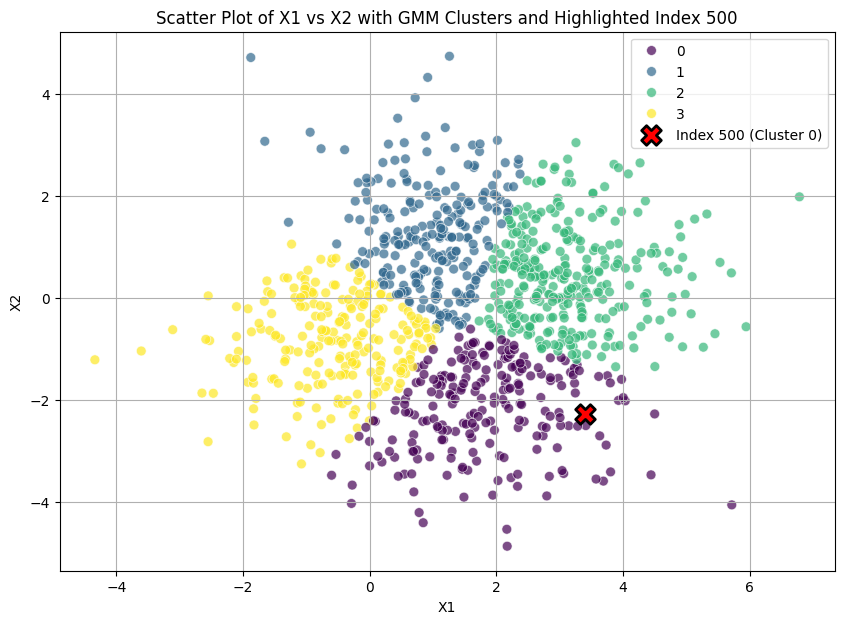

In [ ]:
# Get the coordinates and cluster of the data point at index 500
x1_500 = df.loc[500, 'x1']
x2_500 = df.loc[500, 'x2']
cluster_500 = df.loc[500, 'Cluster']

# Plot the scatter plot with GMM clusters
plt.figure(figsize = (10, 7))
sns.scatterplot(x = 'x1', y = 'x2', hue = 'Cluster', data = df, palette = 'viridis', s = 50, alpha = 0.7)

# Highlight the data point at index 500
plt.scatter(x1_500, x2_500, color = 'red', marker = 'X', s = 200, edgecolor = 'black', linewidth = 2, label = f'Index 500 (Cluster {cluster_500})')

plt.title('Scatter Plot of X1 vs X2 with GMM Clusters and Highlighted Index 500')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True)
plt.legend()
plt.show()

# Conclusion

The Gaussian Mixture Model (GMM) clustering analysis revealed several insights into the dataset's structure.

*   **Gaussianity Tests:** Q-Q plots, Shapiro-Wilk tests, and Kolmogorov-Smirnov tests suggested that while the individual features (x1 and x2) showed some deviation from perfect normality, they were sufficiently close to normal distributions to proceed with GMM, which assumes Gaussian components.

*   **Optimal Number of Clusters:** Different metrics provided varying recommendations for the optimal number of clusters:
    *   **BIC (Bayesian Information Criterion) and Silhouette Score:** Both indicated that 2 clusters might be optimal, as BIC showed its lowest value at 2 clusters, and the Silhouette score was highest for 2 clusters.
    *   **AIC (Akaike Information Criterion):** Suggested 3 clusters as the most suitable, corresponding to its lowest value.
    *   **Davies-Bouldin Index (DBI):** Indicated 4 clusters as the best choice, yielding the lowest DBI score.

*   **Final Clustering with 4 Components:** Despite the conflicting results from some metrics, the analysis proceeded with 4 clusters, consistent with the Davies-Bouldin Index's recommendation. The scatter plot visualization clearly demonstrates four distinct clusters, where data points are assigned based on their probability of belonging to each Gaussian component. For example, the data point at index 500 was assigned to Cluster 0.

In summary, while various statistical methods offer different perspectives on cluster count, a GMM with 4 components provides a visually distinct and interpretable clustering solution for this dataset.